#  Bài toán Linear Regression: Dự đoán Cân nặng từ Chiều cao

Trong bài toán này, chúng ta sẽ xây dựng mô hình Hồi quy tuyến tính (Linear Regression) để dự đoán cân nặng của một người dựa vào chiều cao của họ. 

**Kế hoạch xử lý dữ liệu:**
* Đọc toàn bộ 15 mẫu dữ liệu từ file `data_chieucao_cannang.csv`.
* **Tập kiểm thử (Test set):** Rút ra 2 mẫu có chiều cao là 155 cm và 160 cm để đánh giá mô hình.
* **Tập huấn luyện (Train set):** Sử dụng 13 mẫu còn lại để huấn luyện tìm ra đường thẳng tối ưu có phương trình:
$$y = w_1x + w_0$$

Đã tải thành công! Tập huấn luyện có 13 mẫu.


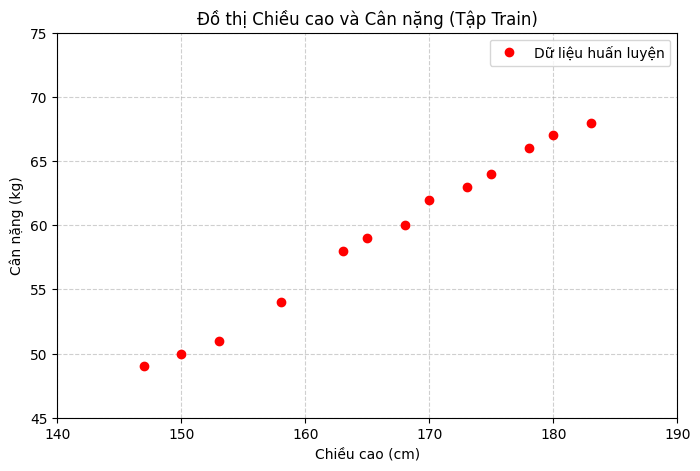

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('data3.csv')

# 2. Phân chia dữ liệu: Cất 2 người (155cm và 160cm) ra làm tập Test
df_test = df[df['Chieu_cao'].isin([155, 160])]

# 3. Giữ lại 13 người làm tập Train
df_train = df[~df['Chieu_cao'].isin([155, 160])]

# 4. Trích xuất ma trận X (Chiều cao) và y (Cân nặng) kích thước (13, 1)
X = df_train[['Chieu_cao']].values
y = df_train[['Can_nang']].values

print(f"Đã tải thành công! Tập huấn luyện có {X.shape[0]} mẫu.")

# 5. Trực quan hóa dữ liệu huấn luyện
plt.figure(figsize=(8, 5))
plt.plot(X, y, 'ro', label='Dữ liệu huấn luyện')
plt.axis([140, 190, 45, 75])
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.title('Đồ thị Chiều cao và Cân nặng (Tập Train)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

###  1. Tìm nghiệm theo công thức Toán học (Đại số tuyến tính)

Từ đồ thị, dữ liệu sắp xếp gần như theo 1 đường thẳng. Chúng ta sẽ tính toán các hệ số $w_1$ và $w_0$ dựa vào công thức giả nghịch đảo (pseudo-inverse) của ma trận:
$$\mathbf{w} = (\mathbf{\bar{X}}^T \mathbf{\bar{X}})^{-1} \mathbf{\bar{X}}^T \mathbf{y}$$

Trong Python, giả nghịch đảo được tính bằng `np.linalg.pinv()`. Ta cần ghép thêm một cột toàn số 1 vào ma trận $\mathbf{X}$ để tạo thành $\mathbf{\bar{X}}$ (tương ứng với hệ số chặn $w_0$).

Vector w = 
 [[-33.73541021]
 [  0.55920496]]


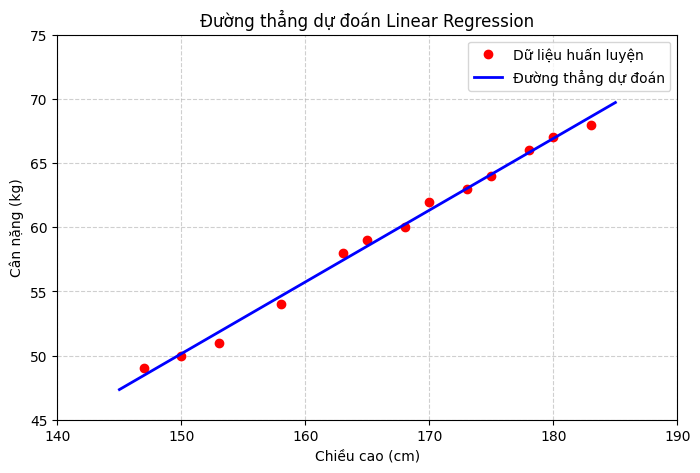

In [2]:
# 1. Xây dựng ma trận Xbar bằng cách thêm cột số 1
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis=1)

# 2. Tính toán ma trận trung gian
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)

# 3. Tính vector trọng số w
w = np.dot(np.linalg.pinv(A), b)
print('Vector w = \n', w)

# 4. Lấy từng hệ số
w_0 = w[0][0]
w_1 = w[1][0]

# 5. Chuẩn bị đường thẳng dự đoán (Fitting line)
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1 * x0

# 6. Vẽ đường thẳng hồi quy lên đồ thị
plt.figure(figsize=(8, 5))
plt.plot(X, y, 'ro', label='Dữ liệu huấn luyện')   # Dữ liệu train
plt.plot(x0, y0, 'b-', linewidth=2, label='Đường thẳng dự đoán') # Đường hồi quy
plt.axis([140, 190, 45, 75])
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.title('Đường thẳng dự đoán Linear Regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

###  2. Đánh giá mô hình trên tập Test

Từ đồ thị, các điểm dữ liệu màu đỏ nằm khá gần đường thẳng dự đoán màu xanh, cho thấy mô hình hoạt động tốt với tập training. 
Bây giờ, chúng ta sử dụng công thức vừa tìm được để dự đoán cân nặng cho 2 người (155 cm và 160 cm) trong tập Test đã cất đi từ đầu.

In [3]:
# Dự đoán dựa trên công thức y = w_1*x + w_0
y1_pred = w_1 * 155 + w_0
y2_pred = w_1 * 160 + w_0

real_155 = df_test[df_test['Chieu_cao'] == 155]['Can_nang'].values[0]
real_160 = df_test[df_test['Chieu_cao'] == 160]['Can_nang'].values[0]

print(f"Dự đoán người cao 155 cm: {y1_pred:.2f} (kg) | Thực tế: {real_155} (kg)")
print(f"Dự đoán người cao 160 cm: {y2_pred:.2f} (kg) | Thực tế: {real_160} (kg)")

Dự đoán người cao 155 cm: 52.94 (kg) | Thực tế: 52 (kg)
Dự đoán người cao 160 cm: 55.74 (kg) | Thực tế: 56 (kg)


### 3. So sánh nghiệm với thư viện `scikit-learn`

Thực tế khi làm dự án, chúng ta sẽ dùng thư viện Machine Learning chuyên nghiệp. Ta sẽ dùng `scikit-learn` để xem thuật toán bên trong thư viện có ra kết quả giống hệt công thức toán học ta tự viết hay không.
*(Lưu ý: Đặt `fit_intercept=False` vì ma trận `Xbar` của chúng ta đã có sẵn cột số 1 cho bias).*

In [4]:
from sklearn import linear_model

# 1. Khởi tạo và huấn luyện mô hình bằng thư viện
regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, y)

# 2. In ra so sánh
print('Nghiệm tìm bởi scikit-learn : ', regr.coef_)
print('Nghiệm tìm bởi công thức toán: ', w.T)

# Kiểm tra logic: Nếu 2 kết quả trừ đi nhau gần bằng 0 thì ta đã code đúng!
difference = np.sum(np.abs(regr.coef_ - w.T))
if difference < 1e-10:
    print("\n THÀNH CÔNG! Kết quả tính tay hoàn toàn khớp với thư viện AI.")

Nghiệm tìm bởi scikit-learn :  [[-33.73541021   0.55920496]]
Nghiệm tìm bởi công thức toán:  [[-33.73541021   0.55920496]]

 THÀNH CÔNG! Kết quả tính tay hoàn toàn khớp với thư viện AI.
